<a href="https://colab.research.google.com/github/abhinavverma0907/SOC-2026-Encryption-and-Decryption/blob/main/Week_2/Assignment/Week_2_Caesar_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random

In [39]:
alphabet = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j',
            'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't',
            'u', 'v', 'w', 'x', 'y', 'z', ' ', '.', ',', ';',
            ':', '/', '@']

N = len(alphabet)  # 33
char_to_idx = {ch: i for i, ch in enumerate(alphabet)}

def encrypt(text, shift):
    result = ""
    for ch in text:
        if ch in char_to_idx:
            result += alphabet[(char_to_idx[ch] + shift) % N]
    return result

print("Alphabet size:", N)

Alphabet size: 33


In [40]:
import urllib.request

url = "https://www.gutenberg.org/files/1342/1342-0.txt"
with urllib.request.urlopen(url) as f:
    raw_text = f.read().decode('utf-8')

print(f"Downloaded {len(raw_text)} characters")
print("Sample:", raw_text[1000:1100])

Downloaded 728846 characters
Sample: 
                       House.        Cross Road.

                                London
          


In [41]:
def clean_text(text):
    text = text.lower()
    cleaned = ""
    for ch in text:
        if ch in char_to_idx:
            cleaned += ch
    return cleaned

text = clean_text(raw_text)
print(f"Cleaned text length: {len(text)} characters")
print("Sample:", text[:100])

Cleaned text length: 705409 characters
Sample:  start of the project gutenberg ebook                              illustration:                    


In [42]:
M = 20
X_data = []
y_data = []

for shift in range(1, N):
    encrypted = encrypt(text, shift)
    for i in range(0, len(encrypted) - M, M):
        chunk = encrypted[i:i+M]
        if len(chunk) == M:
            encoded = [char_to_idx[ch] for ch in chunk]
            X_data.append(encoded)
            y_data.append(shift - 1)

X_data = np.array(X_data, dtype=np.float32)
y_data = np.array(y_data, dtype=np.int64)

print(f"Total samples: {len(X_data)}")
print(f"Samples per shift: ~{len(X_data)//32}")
print(f"Label range: {y_data.min()} to {y_data.max()}")

Total samples: 1128640
Samples per shift: ~35270
Label range: 0 to 31


In [43]:
from torch.utils.data import Dataset, DataLoader

indices = np.random.permutation(len(X_data))
split = int(0.8 * len(X_data))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X_data[train_idx], X_data[test_idx]
y_train, y_test = y_data[train_idx], y_data[test_idx]

print(f"Train samples: {len(X_train)}")
print(f"Test samples:  {len(X_test)}")

class CipherDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(CipherDataset(X_train, y_train),
                          batch_size=64, shuffle=True)
test_loader  = DataLoader(CipherDataset(X_test,  y_test),
                          batch_size=64, shuffle=False)

print("DataLoaders ready")

Train samples: 902912
Test samples:  225728
DataLoaders ready


In [44]:
class CipherMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(M, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

    def forward(self, x):
        return self.net(x)

model = CipherMLP()
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal learnable parameters: {total_params}")

CipherMLP(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
)

Total learnable parameters: 13024


In [45]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 15

train_losses = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += len(y_batch)

    accuracy = correct / total * 100
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

print("\nTraining complete!")

Epoch  1/15 | Loss: 3.2232 | Test Accuracy: 13.38%
Epoch  2/15 | Loss: 2.8669 | Test Accuracy: 19.34%
Epoch  3/15 | Loss: 2.6311 | Test Accuracy: 24.88%
Epoch  4/15 | Loss: 2.4912 | Test Accuracy: 28.31%
Epoch  5/15 | Loss: 2.3885 | Test Accuracy: 28.69%
Epoch  6/15 | Loss: 2.3311 | Test Accuracy: 31.36%
Epoch  7/15 | Loss: 2.2818 | Test Accuracy: 32.46%
Epoch  8/15 | Loss: 2.2432 | Test Accuracy: 34.03%
Epoch  9/15 | Loss: 2.2136 | Test Accuracy: 33.84%
Epoch 10/15 | Loss: 2.1879 | Test Accuracy: 35.13%
Epoch 11/15 | Loss: 2.1650 | Test Accuracy: 36.19%
Epoch 12/15 | Loss: 2.1355 | Test Accuracy: 36.51%
Epoch 13/15 | Loss: 2.0912 | Test Accuracy: 36.80%
Epoch 14/15 | Loss: 2.0624 | Test Accuracy: 38.68%
Epoch 15/15 | Loss: 2.0427 | Test Accuracy: 38.93%

Training complete!


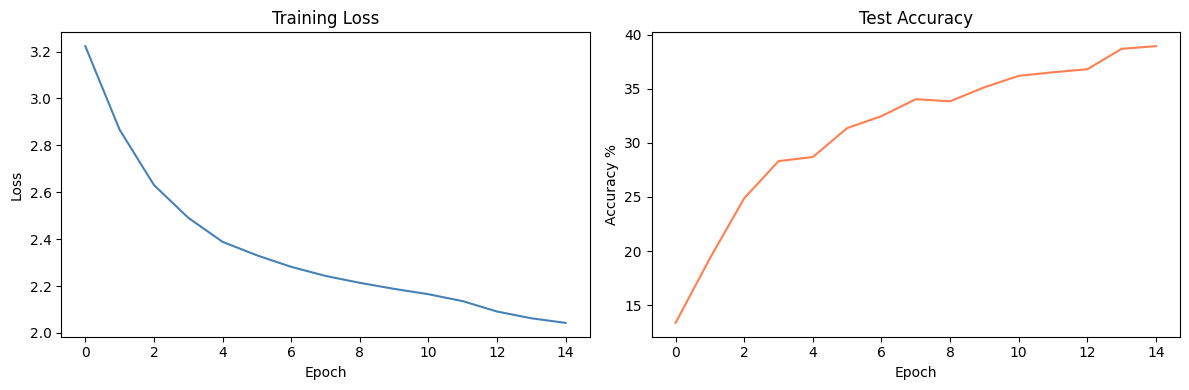

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(test_accuracies, color='coral')
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')

plt.tight_layout()
plt.show()

In [47]:
def predict_shift(ciphertext):
    cleaned = clean_text(ciphertext)[:M]
    if len(cleaned) < M:
        print("Need at least 20 characters!")
        return

    encoded = torch.FloatTensor([[char_to_idx[ch] for ch in cleaned]])

    model.eval()
    with torch.no_grad():
        output = model(encoded)
        predicted_label = torch.argmax(output).item()
        predicted_shift = predicted_label + 1

    print(f"Input (first 20 chars): '{cleaned}'")
    print(f"Predicted shift: {predicted_shift}")
    return predicted_shift

test_plain  = "the quick brown fox jumps over the lazy dog"
test_shift  = 7
test_cipher = encrypt(clean_text(test_plain), test_shift)

print(f"Original:  {test_plain}")
print(f"Encrypted: {test_cipher}")
print()
predicted = predict_shift(test_cipher)
print(f"Actual shift: {test_shift} | Predicted: {predicted} | {'WoW' if predicted == test_shift else 'Shit'}")

Original:  the quick brown fox jumps over the lazy dog
Encrypted:  olax.pjraiyv;uamv:aq.twzav,lya olash@/akvn

Input (first 20 chars): ' olax.pjraiyv;uamv:a'
Predicted shift: 7
Actual shift: 7 | Predicted: 7 | WoW


## Week 2 — MLP for Caesar Cipher Decryption

### Goal
Train an MLP that predicts the Caesar shift (1–32) from a 20-character
chunk of ciphertext — without using frequency analysis or brute force.

### Dataset
- Source: Pride and Prejudice (Project Gutenberg, ~705K characters)
- Cleaned to 33-character alphabet (a-z + space + punctuation)
- Entire text encrypted 32 times — once per shift value (1–32)
- Each 20-character chunk labeled with its shift number
- Total samples: 1,128,640 (~35,270 per shift)
- 80/20 train/test split, shuffled

### Architecture
Input (20) → Linear(128) → ReLU → Linear(64) → ReLU → Linear(32)
- Input: 20 numbers (character indices, 0–32)
- Output: 32 values (one per possible shift), pick the highest
- Total parameters: 13,024

### Results
- Final test accuracy: **38.93%** (still improving at epoch 15)
- Random baseline: 3.125% (1 in 32)
- Loss decreased steadily from 3.22 → 2.04
- Predict test: shift 7 correctly identified

### Observations
The model beats random guessing (3.125%) significantly, reaching 38.93%
accuracy. Loss is still decreasing at epoch 15, suggesting more epochs
would improve results further. The task is harder than Iris (32 classes
vs 3) which explains why accuracy is lower — but the trend is positive.

### Key insight
The MLP learns that certain patterns of character indices correspond to
certain shifts — essentially learning implicit frequency analysis without
being explicitly programmed to do so.